## Unsupervised Learning:
-it will understand the feature

K-means Algorithm: 
K-means it is an unsupervised machine learning algorithm that is used to group similar data points into the clusters.
1.choose k 
2.Assign points to the nearest centroids
3.Calculate the new centroid(mean)
4.assign points again
5.calcuate new centroids
6.repeat 
7.final clusters 


clustering metrices:
1.Inertia:within cluster sum of squares (WCSS)-measure how close points are to their centriods.
lowwer =tigheter clusters 

2.silhoutee Score:metric used in machine learning to evaluate the quality and consistency of of the clusters produced by Kmeans.

s(i) = b(i)-a(i)/(max(a(i),b(i)))
ai = cohesion :average distance between point i and all other points in the same clusters.aalower value means the point fits well inside its clusters.

bi =separation -average distance between points i and all points in the nearest clustering neighbours .
A higher value means point is well separated from other groups.

 

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [19]:
df = pd.read_csv(r"C:\Users\sathi\Desktop\Data Science\Mall_Customers.csv")
df 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [20]:
df.columns , df.shape ,df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


(Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
        'Spending Score (1-100)'],
       dtype='object'),
 (200, 5),
 None)

In [21]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [22]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
print(X.shape)
X.head()


(200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


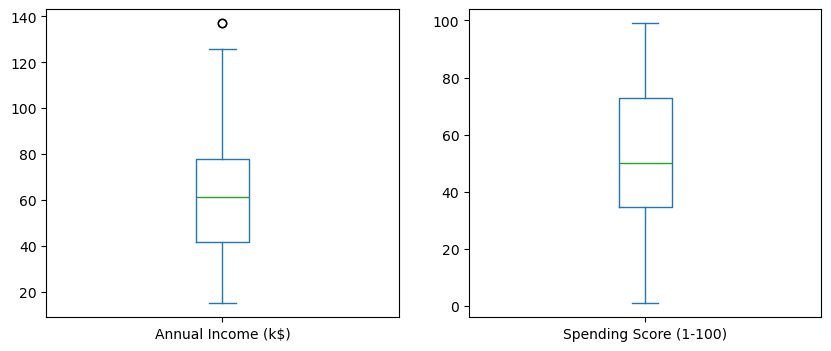

In [23]:
X.plot(kind="box",subplots=True,layout=(1,2),figsize=(10,4))
plt.show()

In [24]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

Annual Income (k$)       -13.250
Spending Score (1-100)   -22.625
dtype: float64 Annual Income (k$)        132.750
Spending Score (1-100)    130.375
dtype: float64


In [25]:
outliers = (X < lower) | (X > upper)
print("Number of outliers:", outliers.sum())

Number of outliers: Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


In [26]:
df[outliers.any(axis=1)]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
print(X_scaled.shape)

(200, 2)


In [29]:
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [30]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

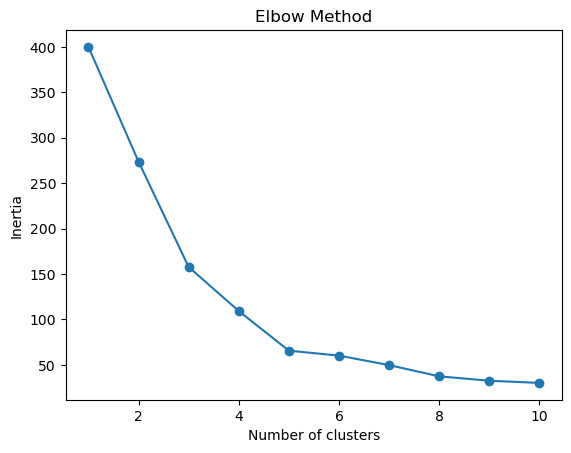

In [31]:
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [32]:
from sklearn.metrics import silhouette_score

sil_score =[]
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score.append(silhouette_score(X_scaled, labels))

c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [33]:
for k , s in zip(range(2, 11), sil_score):
    print(f"Silhouette score for {k} clusters: {s:.4f}")

Silhouette score for 2 clusters: 0.3213
Silhouette score for 3 clusters: 0.4666
Silhouette score for 4 clusters: 0.4939
Silhouette score for 5 clusters: 0.5547
Silhouette score for 6 clusters: 0.5399
Silhouette score for 7 clusters: 0.5281
Silhouette score for 8 clusters: 0.4552
Silhouette score for 9 clusters: 0.4571
Silhouette score for 10 clusters: 0.4432


In [34]:
best_k = range(2,13)[sil_score.index(max(sil_score))]
print(f"Best number of clusters based on silhouette score: {best_k}")

Best number of clusters based on silhouette score: 5


In [35]:
kmeans = KMeans(n_clusters=best_k, random_state=42,n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

c:\Users\sathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


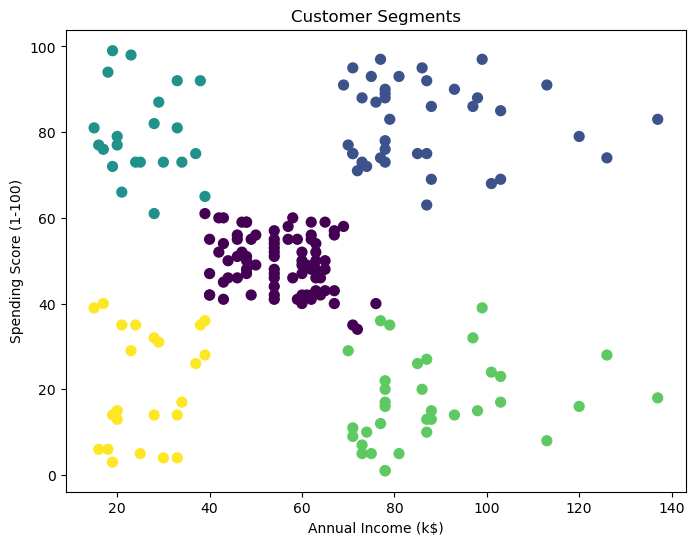

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap='viridis',
    s=50
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()

In [38]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)


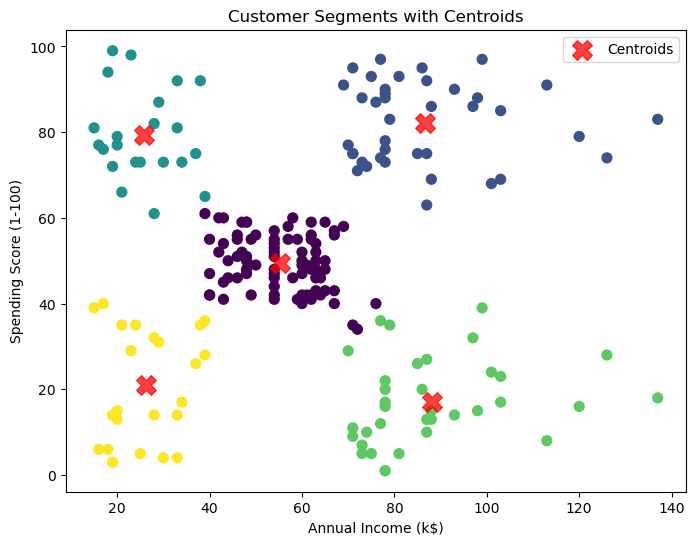

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap='viridis',
    s=50
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    alpha=0.75,
    marker='X',
    label='Centroids'
)
plt.legend()
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments with Centroids")
plt.show()

In [40]:
centers_df = pd.DataFrame(
    centers ,
    columns=["Annual Income (k$)","Spending Score (1-100)"]
)
centers_df["clusters"] = range(5)
centers_df = centers_df.round(1)
centers_df

,Annual Income (k$),Spending Score (1-100),clusters
0,55.3,49.5,0
1,86.5,82.1,1
2,25.7,79.4,2
3,88.2,17.1,3
4,26.3,20.9,4


In [41]:
def name_cluster(income,spending_score):
    if income < 40 and spending_score > 60:
        return "Low income and high spending"
    
    elif income < 40 and spending_score < 40:
        return "Low income and low spending"
    
    elif income > 70 and spending_score > 60:
        return "high income and high spending "
    
    elif income > 70 and spending_score < 40:
        return "high income and low spending"
    else:
        return    "medium income and medium spending"
    
centers_df["Name"]  =centers_df.apply(
    lambda r:name_cluster(r["Annual Income (k$)"],r["Spending Score (1-100)"]),axis=1
)
centers_df

,Annual Income (k$),Spending Score (1-100),clusters,Name
0,55.3,49.5,0,medium income and medium spending
1,86.5,82.1,1,high income and high spending
2,25.7,79.4,2,Low income and high spending
3,88.2,17.1,3,high income and low spending
4,26.3,20.9,4,Low income and low spending


In [42]:
import joblib

joblib.dump(kmeans,"mall_kmeans_model.pkl")
joblib.dump(scaler,"mall_scaler.pkl")

['mall_scaler.pkl']